# Creating Custom Scatterers: Nuclei

Would rather start from ellipsoid, and slightly modify it, than to create a scatterer from scratch in this case?

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import deeptrack as dt

# Depending on your installed version of Deeptrack, you might have to exchange
# the next line for "from deeptrack import units_registry as u"
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable

In [2]:
class EllipsoidShell(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
        thickness=(u.meter, u.meter),
    )

    def __init__(
        self,
        radius=1e-6,        # Use the radius of the ellipsoid, and build the shell outwards
        rotation=0,
        thickness=1e-7, #3e-8,
        **kwargs
    ):
        super().__init__(
            radius=radius,
            rotation=rotation,
            thickness=thickness,
            **kwargs
        )

    def _process_properties(
        self,
        propertydict,
    ):
        """Preprocess the input to the method .get()

        Ensures that the radius and the rotation properties both are arrays of
        length 3.

        If the radius is a single value, the particle is made a sphere
        If the radius are two values, the smallest value is appended as the
        third value

        The rotation vector is padded with zeros until it is of length 3
        """

        propertydict = super()._process_properties(propertydict)

        # Ensure radius has three values.
        radius = np.array(propertydict["radius"])
        if radius.ndim == 0:
            radius = np.array([radius])
        if radius.size == 1:

            # If only one value, assume sphere.
            radius = (*radius,) * 3
        elif radius.size == 2:

            # If two values, duplicate the minor axis.
            radius = (*radius, np.min(radius[-1]))
        elif radius.size == 3:

            # If three values, convert to tuple for consistency.
            radius = (*radius,)
        propertydict["radius"] = radius


        # Ensure rotation has three values.
        rotation = np.array(propertydict["rotation"])
        if rotation.ndim == 0:
            rotation = np.array([rotation])
        if rotation.size == 1:

            # If only one value, pad with two zeros.
            rotation = (*rotation, 0, 0)
        elif rotation.size == 2:

            # If two values, pad with one zero.
            rotation = (*rotation, 0)
        elif rotation.size == 3:

            # If three values, convert to tuple for consistency.
            rotation = (*rotation,)
        propertydict["rotation"] = rotation

        # ensure thickness has a single value
        thickness = np.array(propertydict["thickness"])
        if thickness.ndim == 0:
            thickness = np.array([thickness])
        if thickness.size > 1:
            thickness = thickness[:1]

        return propertydict

    def get(
        self,
        *ignore,
        radius,
        rotation,
        thickness,
        voxel_size,
        **kwargs
    ):
        
        # Create the grid
        rad_ceil = np.ceil((np.max(radius) + thickness) / np.min(voxel_size))

        # Create grid to calculate on.
        x = np.arange(-rad_ceil, rad_ceil) * voxel_size[0]
        y = np.arange(-rad_ceil, rad_ceil) * voxel_size[1]
        z = np.arange(-rad_ceil, rad_ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            (cos[0] * cos[1] * X)
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            (sin[0] * cos[1] * X)
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        outer_mask = (
            (XR / (radius[0] + thickness)) ** 2 +
            (YR / (radius[1] + thickness)) ** 2 +
            (ZR / (radius[2] + thickness)) ** 2 < 1
        ) * 1.0

        inner_mask = (
            (XR / radius[0]) ** 2 +
            (YR / radius[1]) ** 2 +
            (ZR / radius[2]) ** 2 < 1
        ) * 1.0

        mask = outer_mask - inner_mask

        return mask

In [3]:
image_size = 256

max_nucleoli_offset = 15         # in pixels

nucleus_pos = None
def positions():
    global nucleus_pos
    nucleus_pos = np.random.uniform(30, image_size-30, 2)
    return nucleus_pos

def nucleus_position():
    positions()
    return nucleus_pos

def nucleolus_position():
    return nucleus_pos + np.random.uniform(-max_nucleoli_offset, max_nucleoli_offset, 2)

ellipsoid = dt.Ellipsoid(
    radius=(2, 6, 1.5) * dt.units.um,
    transpose=True,
    position=nucleus_position,
    rotation=lambda: np.random.uniform(0, 2 * np.pi), 
    intensity=lambda: np.random.uniform(0.5, 1.5),
    # refractive_index=1.36,
)

envelope = EllipsoidShell(
    radius=ellipsoid.radius,
    thickness=5e-7,
    position=ellipsoid.position,
    rotation=ellipsoid.rotation,
    # refractive_index=1.46,
    intensity=3, 
)

nucleolus = dt.Ellipsoid(
    radius=lambda: np.random.uniform(0.4, 1.2, 3) * dt.units.um,
    position=nucleolus_position,
    rotation=ellipsoid.rotation,
    intensity=ellipsoid.intensity * -1.5,
    # refractive_index=1.39,
)

nucleoli = nucleolus ^ (lambda: np.random.randint(1, 3))

nucleus = (ellipsoid >> envelope >> nucleoli)

noisy_nucleus = (
    nucleus
    >> dt.Pad(px=(10, 10, 10, 10))
    >> dt.ElasticTransformation(alpha=100, sigma=5, ignore_last_dim=False)
    >> dt.CropTight()
)

optics = dt.Fluorescence(
    output_region=(0, 0, image_size, image_size),
    refractive_index_medium=1.37,
)

# pip = optics(ellipsoid) & optics(envelope) & optics(nucleolus) 
# nuclei = (nucleus ^ 1) >> dt.ElasticTransformation(alpha=40, sigma=7)
# non_overlap_nuclei = dt.NonOverlapping(nuclei, min_distance=1)


from skimage import morphology as skmorph

def get_mask(radius):
    """Apply isotropic erosion to a binary mask."""
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius=radius)
        return mask[1:-1, 1:-1]
    return inner

mask_pip_nucleus = (
    noisy_nucleus
    >> dt.SampleToMasks(get_mask, radius=1, output_region=optics.output_region,
                       merge_method="or")
    >> dt.AsType("float")
)

mask_pip_envelope = (
    envelope
    >> dt.SampleToMasks(get_mask, radius=1, output_region=optics.output_region,
                       merge_method="or")
    >> dt.AsType("float")
)


pip = optics(noisy_nucleus) & mask_pip_nucleus & mask_pip_envelope

# optics_b = dt.Brightfield(
#     output_region=optics.output_region,
#     refractive_index_medium=1.37,
#     wavelength=5.5e-7,
#     NA=0.65,
# )

# pip = optics_b(nuclei)

# To Do
- add different refractive indices and intensities for the different parts of the cell
    * check that it looks reasonable in fluorescence and brightfield

- find out how to add elastic transformation to the shell and nucleus together

- add noise to the simulation

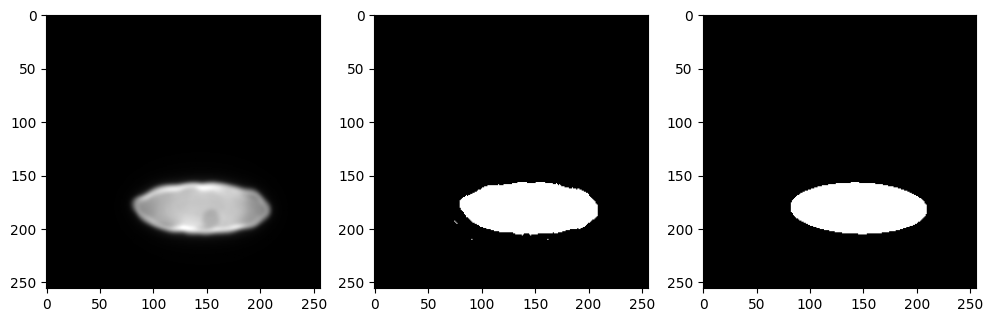

In [4]:
pip.update()
image, mask1, mask2 = pip.resolve()

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(image, cmap='gray')
ax[1].imshow(mask1, cmap='gray')
ax[2].imshow(mask2, cmap='gray');

Is the elastic transformation applied to stacked objects "together" or separately? --> Try on a simpler example

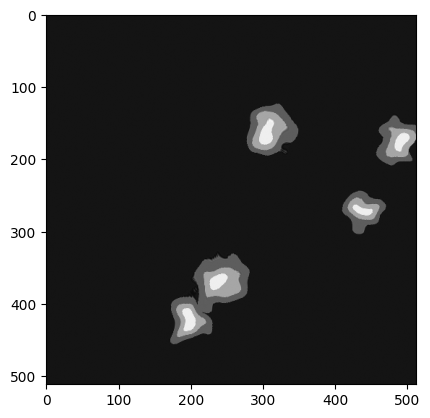

In [5]:
class Circle(dt.Feature):
    """Feature that adds a circle to the image."""

    def get(self, image, position, radius, intensity, **kwargs):
        X, Y = np.meshgrid(np.arange(image.shape[0]),
                           np.arange(image.shape[1]))
        mask = (X - position[0]) ** 2 + (Y - position[1]) ** 2 < radius ** 2
        image[mask] = intensity
        return image

circle1 = Circle(
    position=lambda: np.random.rand(2) * 512,
    radius=lambda: 20 + np.random.rand() * 20,
    intensity=1,
)

# Add a circle with 2/3 the radius and 2 times the intensity of circle1.
circle2 = Circle(
    position=circle1.position,
    radius=circle1.radius * 0.66,
    intensity=circle1.intensity * 2,
)

# Add a circle with 1/3 the radius and 3 times the intensity of circle1.
circle3 = Circle(
    position=circle1.position,
    radius=circle1.radius * 0.33,
    intensity=circle1.intensity * 3,
)


stacked_circles = circle1 >> circle2 >> circle3

many_stacked_circles = (
    (stacked_circles ^ (lambda: np.random.randint(5, 10)))
    >> dt.ElasticTransformation(alpha=250, sigma=8, ignore_last_dim=False, mode='constant')
)
    

input_image = np.zeros((512, 512))

output_image = many_stacked_circles.update()(input_image) 

plt.imshow(output_image, cmap="gray")
plt.show()

Simpler simulation, inspired by cell_counting notebook. Works for fluorescence microscopy. Can we make it look okay for brightfield too?

In [6]:
image_size = 128

ellipsoid = dt.Ellipsoid(
    radius=lambda: (np.random.uniform(5, 7),
                      np.random.uniform(4, 6),
                      np.random.uniform(3, 5)) * dt.units.um,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=(64, 64), #lambda: np.random.uniform(5, image_size - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

small_ellipsoid = dt.Ellipsoid(
    radius=lambda: (np.random.uniform(1, 1.8),
                    np.random.uniform(1, 1.8),
                      np.random.uniform(1, 1.5)) * dt.units.um,
    intensity=ellipsoid.intensity * -1, #lambda: np.random.uniform(-0.6, -0.3),
    position=ellipsoid.position,
)

stacked_ellipsoids = ellipsoid >> small_ellipsoid

synthetic_nuclei = (
    (stacked_ellipsoids)# ^ (lambda: np.random.randint(5, 10)))
    >> dt.Pad(px=(10, 10, 10, 10), keep_size=False)
    >> dt.ElasticTransformation(alpha=100, sigma=10)
    >> dt.CropTight()
)

synthetic_nuclei_mask = synthetic_nuclei > 0

long_range_noise = (synthetic_nuclei >> dt.Poisson(snr=0.2)
                    >> dt.GaussianBlur(sigma=3.5))
short_range_noise = (synthetic_nuclei >> dt.Poisson(snr=1.0)
                     >> dt.GaussianBlur(sigma=1.5))
random_range_noise = (
    synthetic_nuclei
    >> dt.Poisson(snr=0.2)#lambda: np.random.uniform(0.2, 1))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.75, 1.5))
)
noisy_synthetic_nuclei = (
    synthetic_nuclei_mask
    * (long_range_noise + short_range_noise + random_range_noise) / 3
)

# non_overlap_nuclei = dt.NonOverlapping(noisy_synthetic_nuclei, min_distance=6)

In [7]:
optics = dt.Fluorescence()

pip = optics(noisy_synthetic_nuclei)

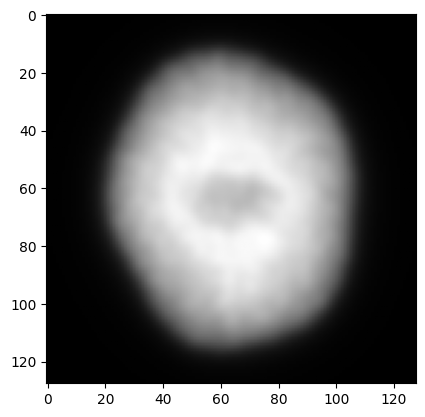

In [8]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

In [9]:
optics = dt.Brightfield()

pip = optics(noisy_synthetic_nuclei)

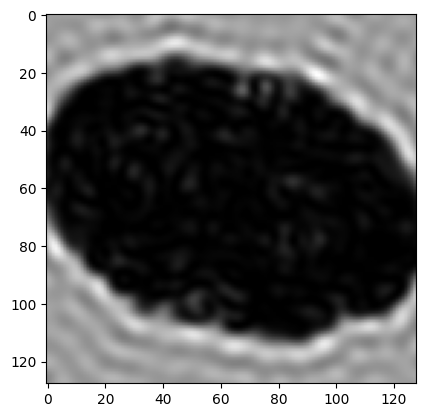

In [10]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');